# Cycle and spectral analysis

Cycle and spectral analysis measures the dominant cycle of a series and its
instantaneous phase, frequency, and amplitude. The estimate comes from the
analytic signal built with a Hilbert transform, following the method John
Ehlers developed for market data. The same machinery applies to any sampled
waveform: audio, biomedical traces, vibration, and radar all carry an
oscillation whose period drifts over time.

This notebook works in samples and cycles per sample, not calendar units, so it
reads the same whether the series is a price, a sensor channel, or a tone. Every
operator here is causal: its value at each sample depends only on that sample
and earlier ones, and each one emits `NaN` through a short warm-up transient
before its internal filters fill.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from screamer import (RoofingFilter, HilbertPhasor, DominantCycle, CyclePhase,
                      CycleFrequency, CycleAmplitude, CycleSine, TrendMode,
                      MAMA, InstantaneousTrendline, EwMean)

SEED = 20
rng = np.random.default_rng(SEED)


def finish(ax, title, xlabel="sample", ylabel=None, ncol=1):
    "Apply the shared panel styling: title, axis labels, and a small legend."
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.legend(loc="upper right", fontsize=8, ncol=ncol)

## The analytic signal

The chain starts by isolating the oscillation, then splitting it into two
quadrature components. `RoofingFilter(hp_period=, lp_period=)` is a bandpass
preprocessor: its high-pass arm removes slow trend and its low-pass arm removes
fast noise, leaving the band that carries the cycle. `HilbertPhasor` then returns
two columns, the in-phase component `I` and the quadrature component `Q`, which
are the same wave a quarter cycle apart. The pair is the analytic signal every
later estimate reads from.

The input below is a tone of period 20 samples riding on a slow linear trend
with mild broadband noise added.

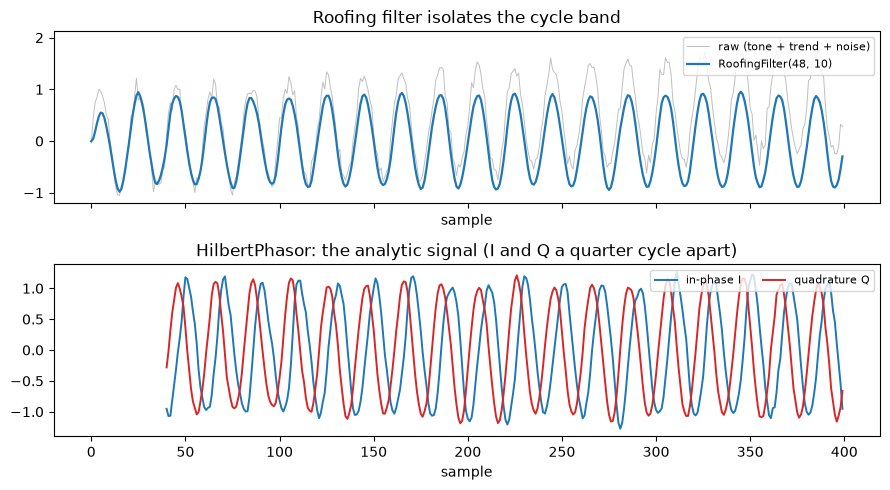

In [2]:
n = 400
t = np.arange(n)
tone = np.sin(2 * np.pi * t / 20)
raw = tone + 0.002 * t + 0.10 * rng.standard_normal(n)   # tone + slow trend + noise

band = RoofingFilter(hp_period=48, lp_period=10)(raw)
inphase, quad = HilbertPhasor()(raw).T

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax0.plot(raw, lw=0.7, color="0.75", label="raw (tone + trend + noise)")
ax0.plot(band, lw=1.6, color="C0", label="RoofingFilter(48, 10)")
finish(ax0, "Roofing filter isolates the cycle band")

ax1.plot(inphase, lw=1.4, color="C0", label="in-phase I")
ax1.plot(quad, lw=1.4, color="C3", label="quadrature Q")
finish(ax1, "HilbertPhasor: the analytic signal (I and Q a quarter cycle apart)", ncol=2)
plt.tight_layout()

## Dominant cycle

`DominantCycle` reports the period of the strongest oscillation at each sample,
in samples per cycle. To show that it tracks a moving target, the input holds a
period of 16 for the first half and 30 for the second half, with mild noise. The
recovered period follows the true period after the warm-up transient and settles
again a few dozen samples after the step.

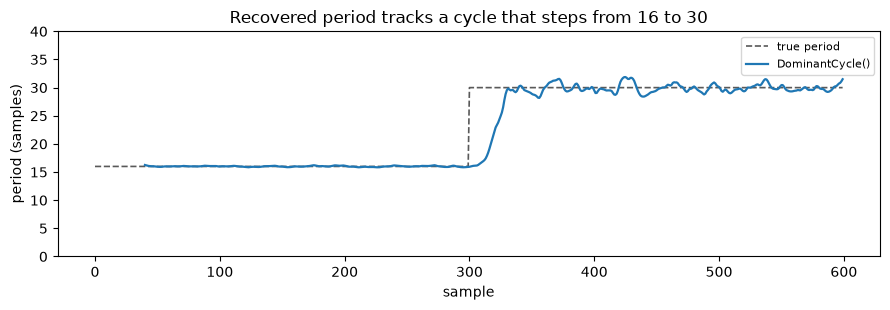

In [3]:
m = 600
half = m // 2
true_period = np.where(np.arange(m) < half, 16.0, 30.0)
angle = np.cumsum(2 * np.pi / true_period)
signal = np.sin(angle) + 0.08 * rng.standard_normal(m)

period = DominantCycle()(signal)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(true_period, lw=1.2, color="0.35", ls="--", label="true period")
ax.plot(period, lw=1.6, color="C0", label="DominantCycle()")
ax.set_ylim(0, 40)
finish(ax, "Recovered period tracks a cycle that steps from 16 to 30", ylabel="period (samples)")
plt.tight_layout()

## Phase, frequency, and amplitude

Three operators read further detail off the same analytic signal.
`CyclePhase` returns the position within the current cycle as a sawtooth from 0
to 360 degrees. `CycleFrequency` returns cycles per sample, the reciprocal of the
period, so a period-20 tone sits near 0.05. `CycleAmplitude` returns the envelope,
the size of the oscillation. The input here is an amplitude-modulated tone: a
period-20 carrier whose envelope rises and falls on a period of 220, so the
tracked amplitude has something to follow. `CycleAmplitude` carries a small high
bias of several percent, visible as the estimate sitting above the true
envelope.

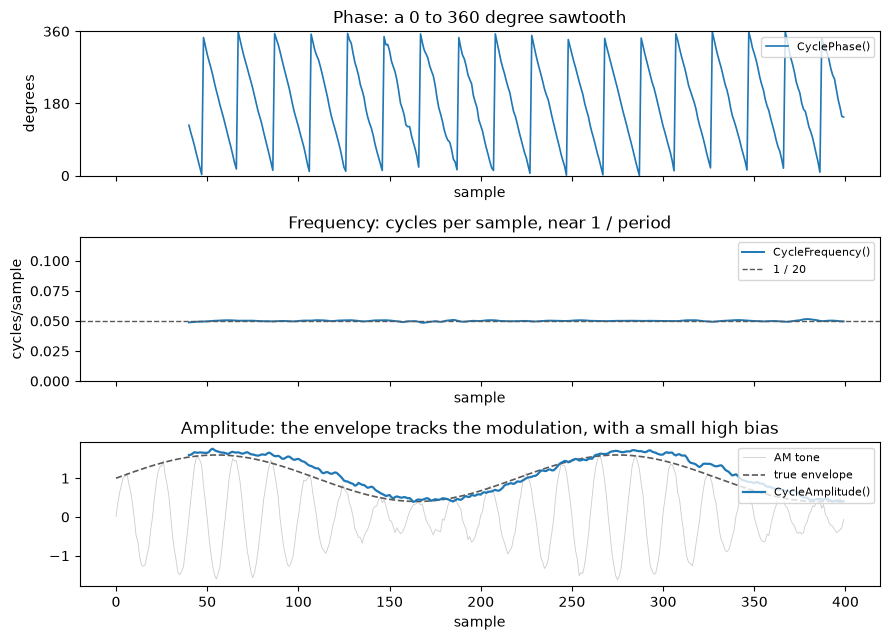

In [4]:
k = 400
tt = np.arange(k)
envelope = 1.0 + 0.6 * np.sin(2 * np.pi * tt / 220)
am_tone = envelope * np.sin(2 * np.pi * tt / 20) + 0.05 * rng.standard_normal(k)

phase = CyclePhase()(am_tone)
freq = CycleFrequency()(am_tone)
amp = CycleAmplitude()(am_tone)

fig, (axp, axf, axa) = plt.subplots(3, 1, figsize=(9, 6.5), sharex=True)
axp.plot(phase, lw=1.2, color="C0", label="CyclePhase()")
axp.set_ylim(0, 360)
axp.set_yticks([0, 180, 360])
finish(axp, "Phase: a 0 to 360 degree sawtooth", ylabel="degrees")

axf.plot(freq, lw=1.4, color="C0", label="CycleFrequency()")
axf.axhline(1 / 20, color="0.35", ls="--", lw=1.0, label="1 / 20")
axf.set_ylim(0, 0.12)
finish(axf, "Frequency: cycles per sample, near 1 / period", ylabel="cycles/sample")

axa.plot(am_tone, lw=0.6, color="0.8", label="AM tone")
axa.plot(envelope, lw=1.2, color="0.35", ls="--", label="true envelope")
axa.plot(amp, lw=1.6, color="C0", label="CycleAmplitude()")
finish(axa, "Amplitude: the envelope tracks the modulation, with a small high bias")
plt.tight_layout()

## Sinewave indicator and trend mode

`CycleSine` returns two columns, a sine of the current cycle phase and a
`leadsine` advanced by 45 degrees. Their crossings mark cycle turns: the pair
crosses as the phase passes the peaks and troughs of the oscillation, one lead
ahead of the other.

`TrendMode` classifies each sample as trending (`1.0`) or cycling (`0.0`). It
compares the per-sample phase advance to the rate expected for the current
dominant cycle; when the advance stalls well below that rate, the cycle has
stopped rotating and the sample is called trending. The input below oscillates
cleanly for its first half, then follows a smooth ramp. The flag stays off
through the oscillation and switches on within the trending stretch.

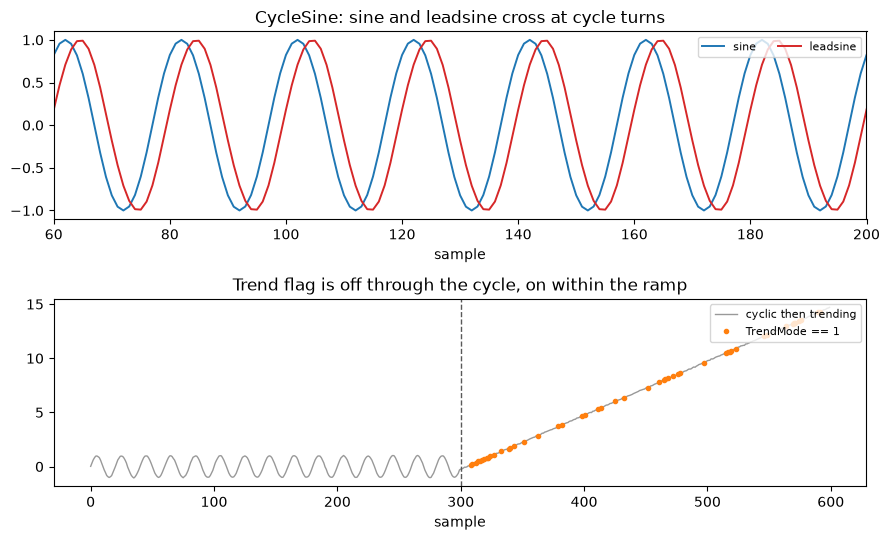

In [5]:
c = 300
cycle_part = np.sin(2 * np.pi * np.arange(c) / 20)
ramp_part = cycle_part[-1] + 0.05 * np.arange(1, c + 1)
mixed = np.concatenate([cycle_part, ramp_part]) + 0.02 * rng.standard_normal(2 * c)

sine, leadsine = CycleSine()(cycle_part).T
mode = TrendMode(phase_rate_frac=0.5)(mixed)

fig, (axs, axm) = plt.subplots(2, 1, figsize=(9, 5.5))
axs.plot(sine, lw=1.4, color="C0", label="sine")
axs.plot(leadsine, lw=1.4, color="C3", label="leadsine")
axs.set_xlim(60, 200)
finish(axs, "CycleSine: sine and leadsine cross at cycle turns", ncol=2)

trend_hits = np.where(mode == 1.0)[0]
axm.plot(mixed, lw=1.0, color="0.6", label="cyclic then trending")
axm.plot(trend_hits, mixed[trend_hits], "o", ms=3, color="C1", label="TrendMode == 1")
axm.axvline(c, color="0.35", ls="--", lw=1.0)
finish(axm, "Trend flag is off through the cycle, on within the ramp")
plt.tight_layout()

## Adaptive smoothing

The dominant cycle can retune a smoother on the fly. `MAMA` returns two columns,
the MESA adaptive moving average and its slower follower `FAMA`. It speeds up
when the measured phase moves fast and slows down when the phase stalls, so its
lag shrinks on quick turns and grows on quiet stretches. `InstantaneousTrendline`
is a matched trend estimate from the same cycle measurement. A fixed
`EwMean(span=20)` is shown for contrast: it holds one smoothing rate for the whole
series, so it cannot tighten on a fast turn the way `MAMA` does.

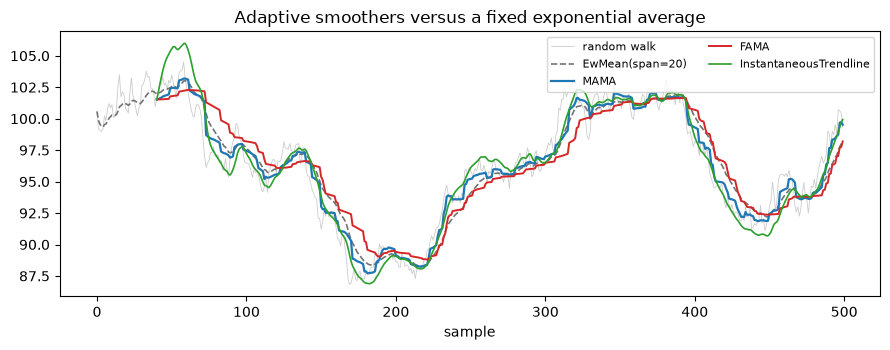

In [6]:
w = 500
walk = 100 + np.cumsum(0.7 * rng.standard_normal(w))

mama, fama = MAMA(fast_limit=0.5, slow_limit=0.05)(walk).T
trendline = InstantaneousTrendline()(walk)
ew = EwMean(span=20)(walk)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(walk, lw=0.6, color="0.8", label="random walk")
ax.plot(ew, lw=1.2, color="0.45", ls="--", label="EwMean(span=20)")
ax.plot(mama, lw=1.6, color="C0", label="MAMA")
ax.plot(fama, lw=1.4, color="C3", label="FAMA")
ax.plot(trendline, lw=1.2, color="C2", label="InstantaneousTrendline")
finish(ax, "Adaptive smoothers versus a fixed exponential average", ncol=2)
plt.tight_layout()

## On real market data

The same operators run on a real price series. The data is a six-hour slice of
Deribit BTC-perpetual trades from 2023-08-04, committed under `data/`. Taking
every sixth tick gives a manageable series of a few hundred samples while keeping
the real path. `DominantCycle` reports the period of the strongest oscillation,
`MAMA` and `FAMA` track the level, and `TrendMode` flags the trending stretches.

683 samples   median dominant cycle 24.7 samples


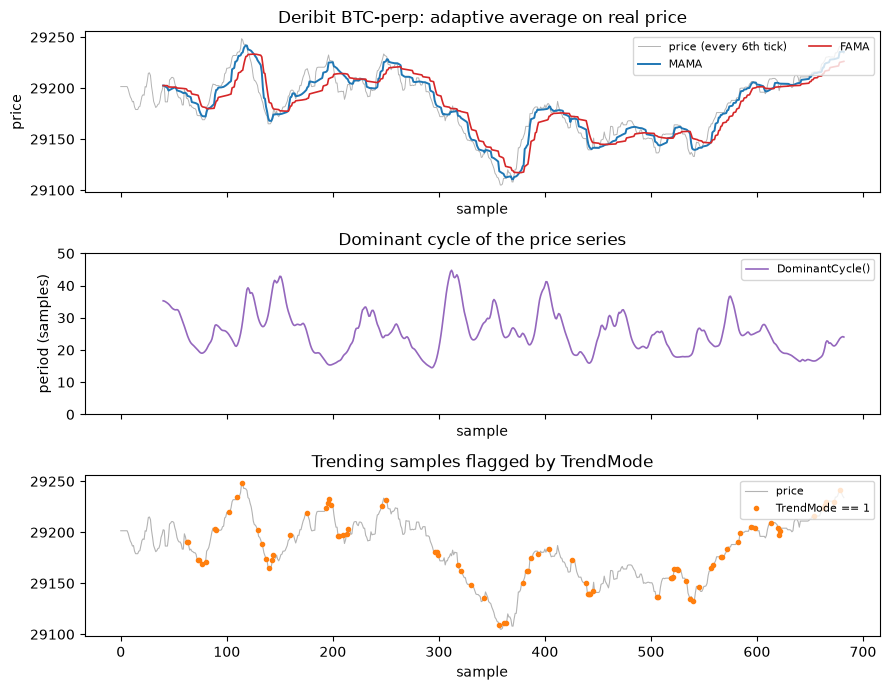

In [7]:
data_path = Path("data/deribit_btc_perp_6h.csv")
if not data_path.is_file():
    data_path = Path("docs/notebooks/data/deribit_btc_perp_6h.csv")
if not data_path.is_file():
    raise FileNotFoundError(
        "Bundled Deribit sample data not found. Run this notebook from the repository root or docs/notebooks."
    )

trades = pd.read_csv(data_path)
price = trades["price"].to_numpy(np.float64)[::6]     # every sixth tick

r_period = DominantCycle()(price)
r_mama, r_fama = MAMA(fast_limit=0.5, slow_limit=0.05)(price).T
r_mode = TrendMode(phase_rate_frac=0.5)(price)

print(f"{len(price):,} samples   median dominant cycle {np.nanmedian(r_period):.1f} samples")

fig, (axp, axc, axt) = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axp.plot(price, lw=0.7, color="0.7", label="price (every 6th tick)")
axp.plot(r_mama, lw=1.4, color="C0", label="MAMA")
axp.plot(r_fama, lw=1.2, color="C3", label="FAMA")
finish(axp, "Deribit BTC-perp: adaptive average on real price", ylabel="price", ncol=2)

axc.plot(r_period, lw=1.2, color="C4", label="DominantCycle()")
axc.set_ylim(0, 50)
finish(axc, "Dominant cycle of the price series", ylabel="period (samples)")

hits = np.where(r_mode == 1.0)[0]
axt.plot(price, lw=0.8, color="0.7", label="price")
axt.plot(hits, price[hits], "o", ms=3, color="C1", label="TrendMode == 1")
finish(axt, "Trending samples flagged by TrendMode")
plt.tight_layout()